In [1]:
%load_ext autoreload
%autoreload 2
%cd /opt/tiger/samantha

/mnt/bd/janne-research-sm/samantha


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [23]:
from recipes.research.dataset.parquet_dataset import FeatureParquetDataset
from samantha.data.audio.dataset import AudioFolderDataModule

segment_duration = 30

batch_size = 8
num_workers = 8

dataset = FeatureParquetDataset(
    data_id=270,
    resampled=False,
    shardshuffle=False,
    segment_duration=segment_duration,
    sample_rate=24000,
    channels=1,
    frame_rate=100,
    shuffle_buffer_size=0,
    data_type="music_vocal",
    nitems=213,
    crop_from_start=True,
)


datamodule = AudioFolderDataModule(
    train_datasets=[dataset],
    validation_datasets=[],
    test_datasets=[],
    weights=None,
    batch_size=batch_size,
    shuffle=None,
    num_workers=num_workers,
    batch_drop_duplicates=True,
)

dataloader = iter(datamodule.train_dataloader())

2024-07-09 13:22:17,715 - bytedance.easycycle.bigspeech - INFO - region: Region.I18n
2024-07-09 13:22:17,715 - bytedance.easycycle.bigspeech - INFO - req body: {"id": 270, "arnold_trail_id": "6060089", "arnold_debug": "autonomous"}, headers: {'content-type': 'application/json'}
2024-07-09 13:22:17,774 - bytedance.easycycle.bigspeech - INFO - post https://bigspeech.byteintl.net/platform/api/v3/data/dataset_collection/get_dataset_collection_info_v2, status code: 200, body: {"origin":{"paths":[{"data":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_artist_sft_radiohead_24khz_mel_160m_2048fft_240hl/data//part=*/*.parquet","index":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_artist_sft_radiohead_24khz_mel_160m_2048fft_240hl/index_1//part=*/*.parquet","repetitions":"1"}]},"ratio":null,"sampling_type":"origin"}, headers: {'Date': 'Tue, 09 Jul 2024 05:22:17 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Enco

parse urls:   0%|          | 0/1 [00:00<?, ?it/s]

2024-07-09 13:22:18,919 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_artist_sft_radiohead_24khz_mel_160m_2048fft_240hl/index_1//part=*


parse urls: 100%|██████████| 1/1 [00:02<00:00,  2.16s/it]

2024-07-09 13:22:20,014 - samantha.data.audio.dataset - INFO - Training datasets:
2024-07-09 13:22:20,014 - samantha.data.audio.dataset - INFO - [<recipes.research.dataset.parquet_dataset.FeatureParquetDataset object at 0x7f8f167447c0>]
2024-07-09 13:22:20,015 - samantha.data.audio.dataset - INFO - Total samples: 213


In [29]:
batch = next(dataloader)

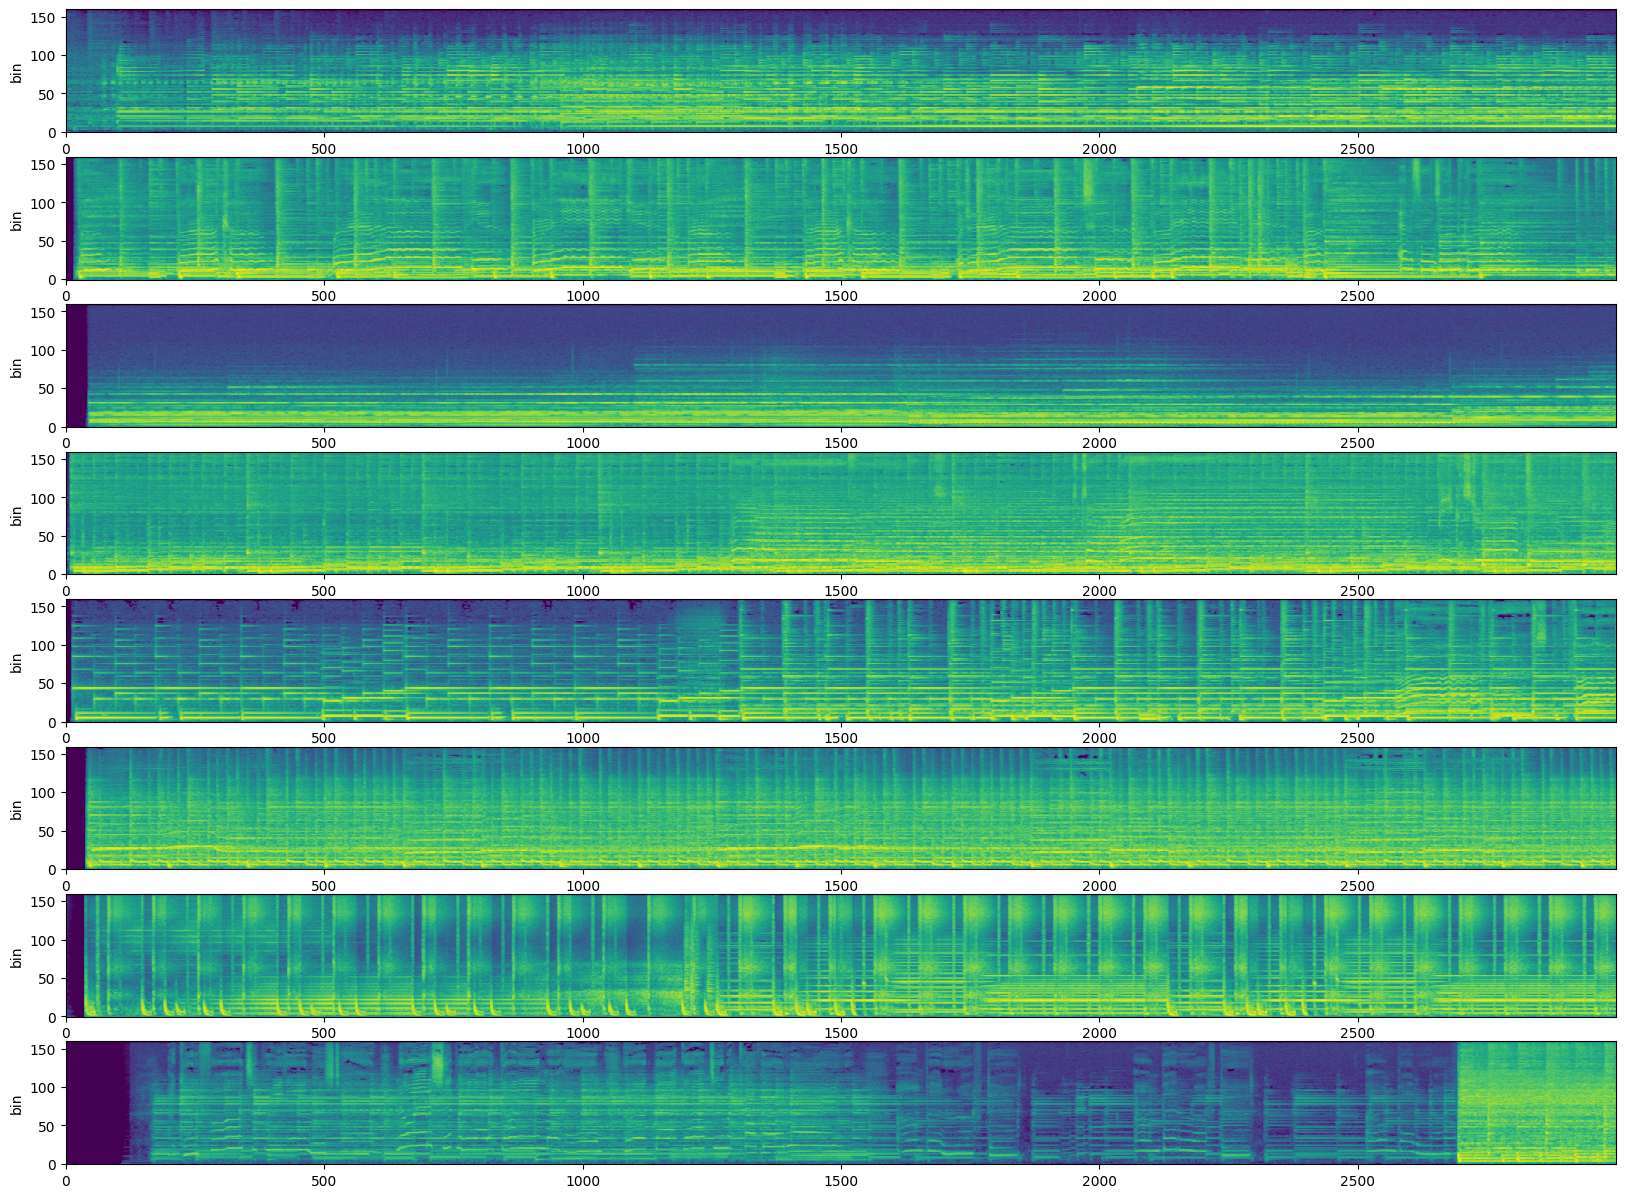

In [30]:
from samantha.transforms.audio import batch_plot_spectrogram

batch_plot_spectrogram(batch.audio, plot_log=False, figsize=(20, 15))